# Notebook con las señales simuladas como glitches

In [5]:
import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("cwd:", Path.cwd())
print("src_path:", src_path)
print("exists:", src_path.exists())

cwd: c:\dev\glitchlab\notebooks
src_path: c:\dev\glitchlab\src
exists: True


## A) Signal in time-domain and spectrogram

The supported types of signal are:

- **Noise**: Standard gaussian noise with zero-mean and default `std=0.1`.
- **Sine Gaussian**: Glitch that is a product of a sinusoidal wave and a Gaussian envelope. Params: `f0`, `sigma`, `amplitude`
- **Ringdown**: A ringdown glitch is a transient signal characterized by a sinusoidal component with an exponential decay. Params: `f0`, `tau`, `amplitude`

Parameters can be given in a `dict`, otherwise they are generated.

In [6]:
import sys
print(sys.executable)

import scipy
print(scipy.__version__)
print(scipy.__file__)

from scipy.signal import spectrogram
print("spectrogram ok")

c:\Users\victo\miniforge3\envs\glitchlab\python.exe
1.17.1
c:\Users\victo\miniforge3\envs\glitchlab\Lib\site-packages\scipy\__init__.py
spectrogram ok


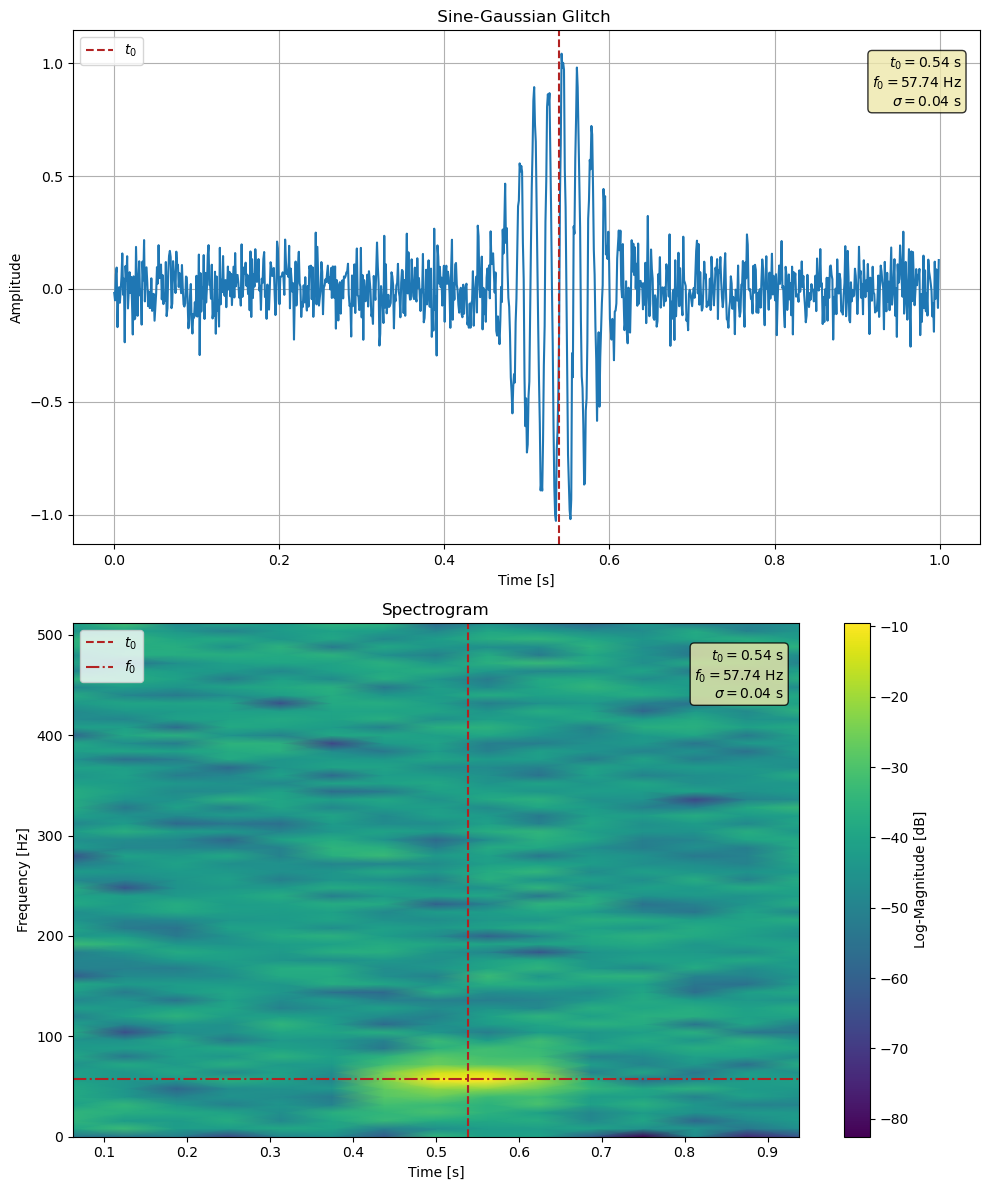

In [7]:
from signals import SignalGenerator
from features import FeatureExtractor
from plotting import plot_sample

sg = SignalGenerator()
fe = FeatureExtractor()

signal, label, metadata = sg.generate_sample(glitch_type=None) #Supported types ['noise', 'sine_gaussian', 'ringdown'], if None the glitch is randomly generated given a probability
f, t_spec, Sxx_db = fe.build_spectrogram(signal)

_ , _ = plot_sample(sg.t, signal, f, t_spec, Sxx_db, label=label, metadata=metadata, show_params=True)


## C) Glitch and noise morphologies

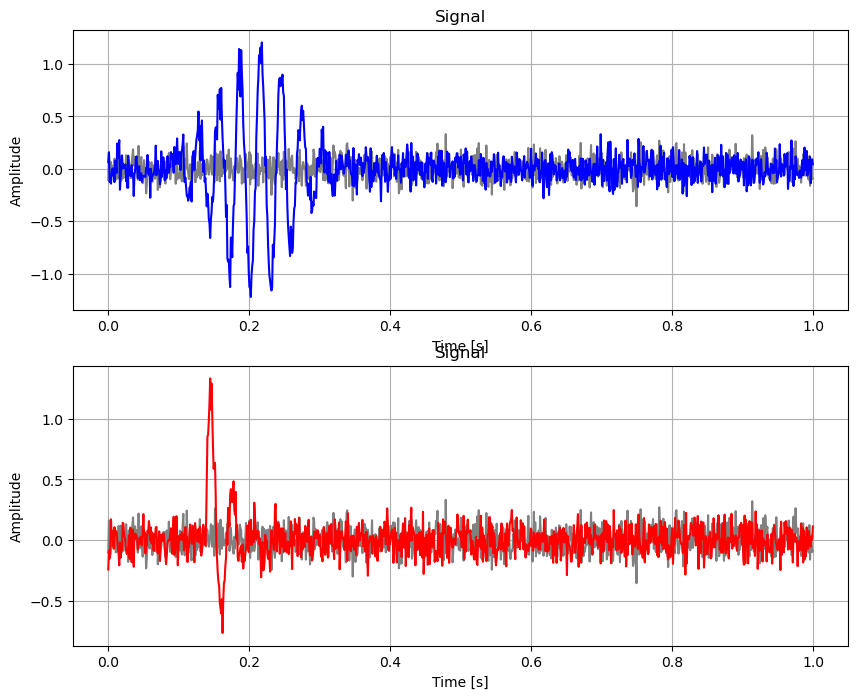

In [8]:
from signals import SignalGenerator
from plotting import plot_sample, plot_signal

import matplotlib.pyplot as plt

sg = SignalGenerator()

sine_gaussian_params = {    
    'f0': 32,
    'sigma': 0.10,
    'amplitude': 1
}

noise_sample, _, noise_metadata = sg.generate_sample(glitch_type='noise')
glitch_sample, _, glitch_metadata = sg.generate_sample(glitch_type='sine_gaussian')
ringdown_sample, _, ringdown_metadata = sg.generate_sample(glitch_type='ringdown')

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

_, _ = plot_signal(sg.t, noise_sample, ax=ax[0], color='gray', show=True)
_, _ = plot_signal(sg.t, glitch_sample, ax=ax[0], color='blue', show=True) 

_, _ = plot_signal(sg.t, noise_sample, ax=ax[1], color='gray', show=True)
_, _ = plot_signal(sg.t, ringdown_sample, ax=ax[1], color='red')



## D) Generating a Dataset

A dataset with noise, and glitches of type sine-gaussian and ringdown is built for `n_samples=100`. Although only 12 are shown here.

The default probabilities are:

- $p_{noise}=50\%$,
- $p_{sin-gaussian}=25\%$ and
- $p_{ringdown}=25\%$.

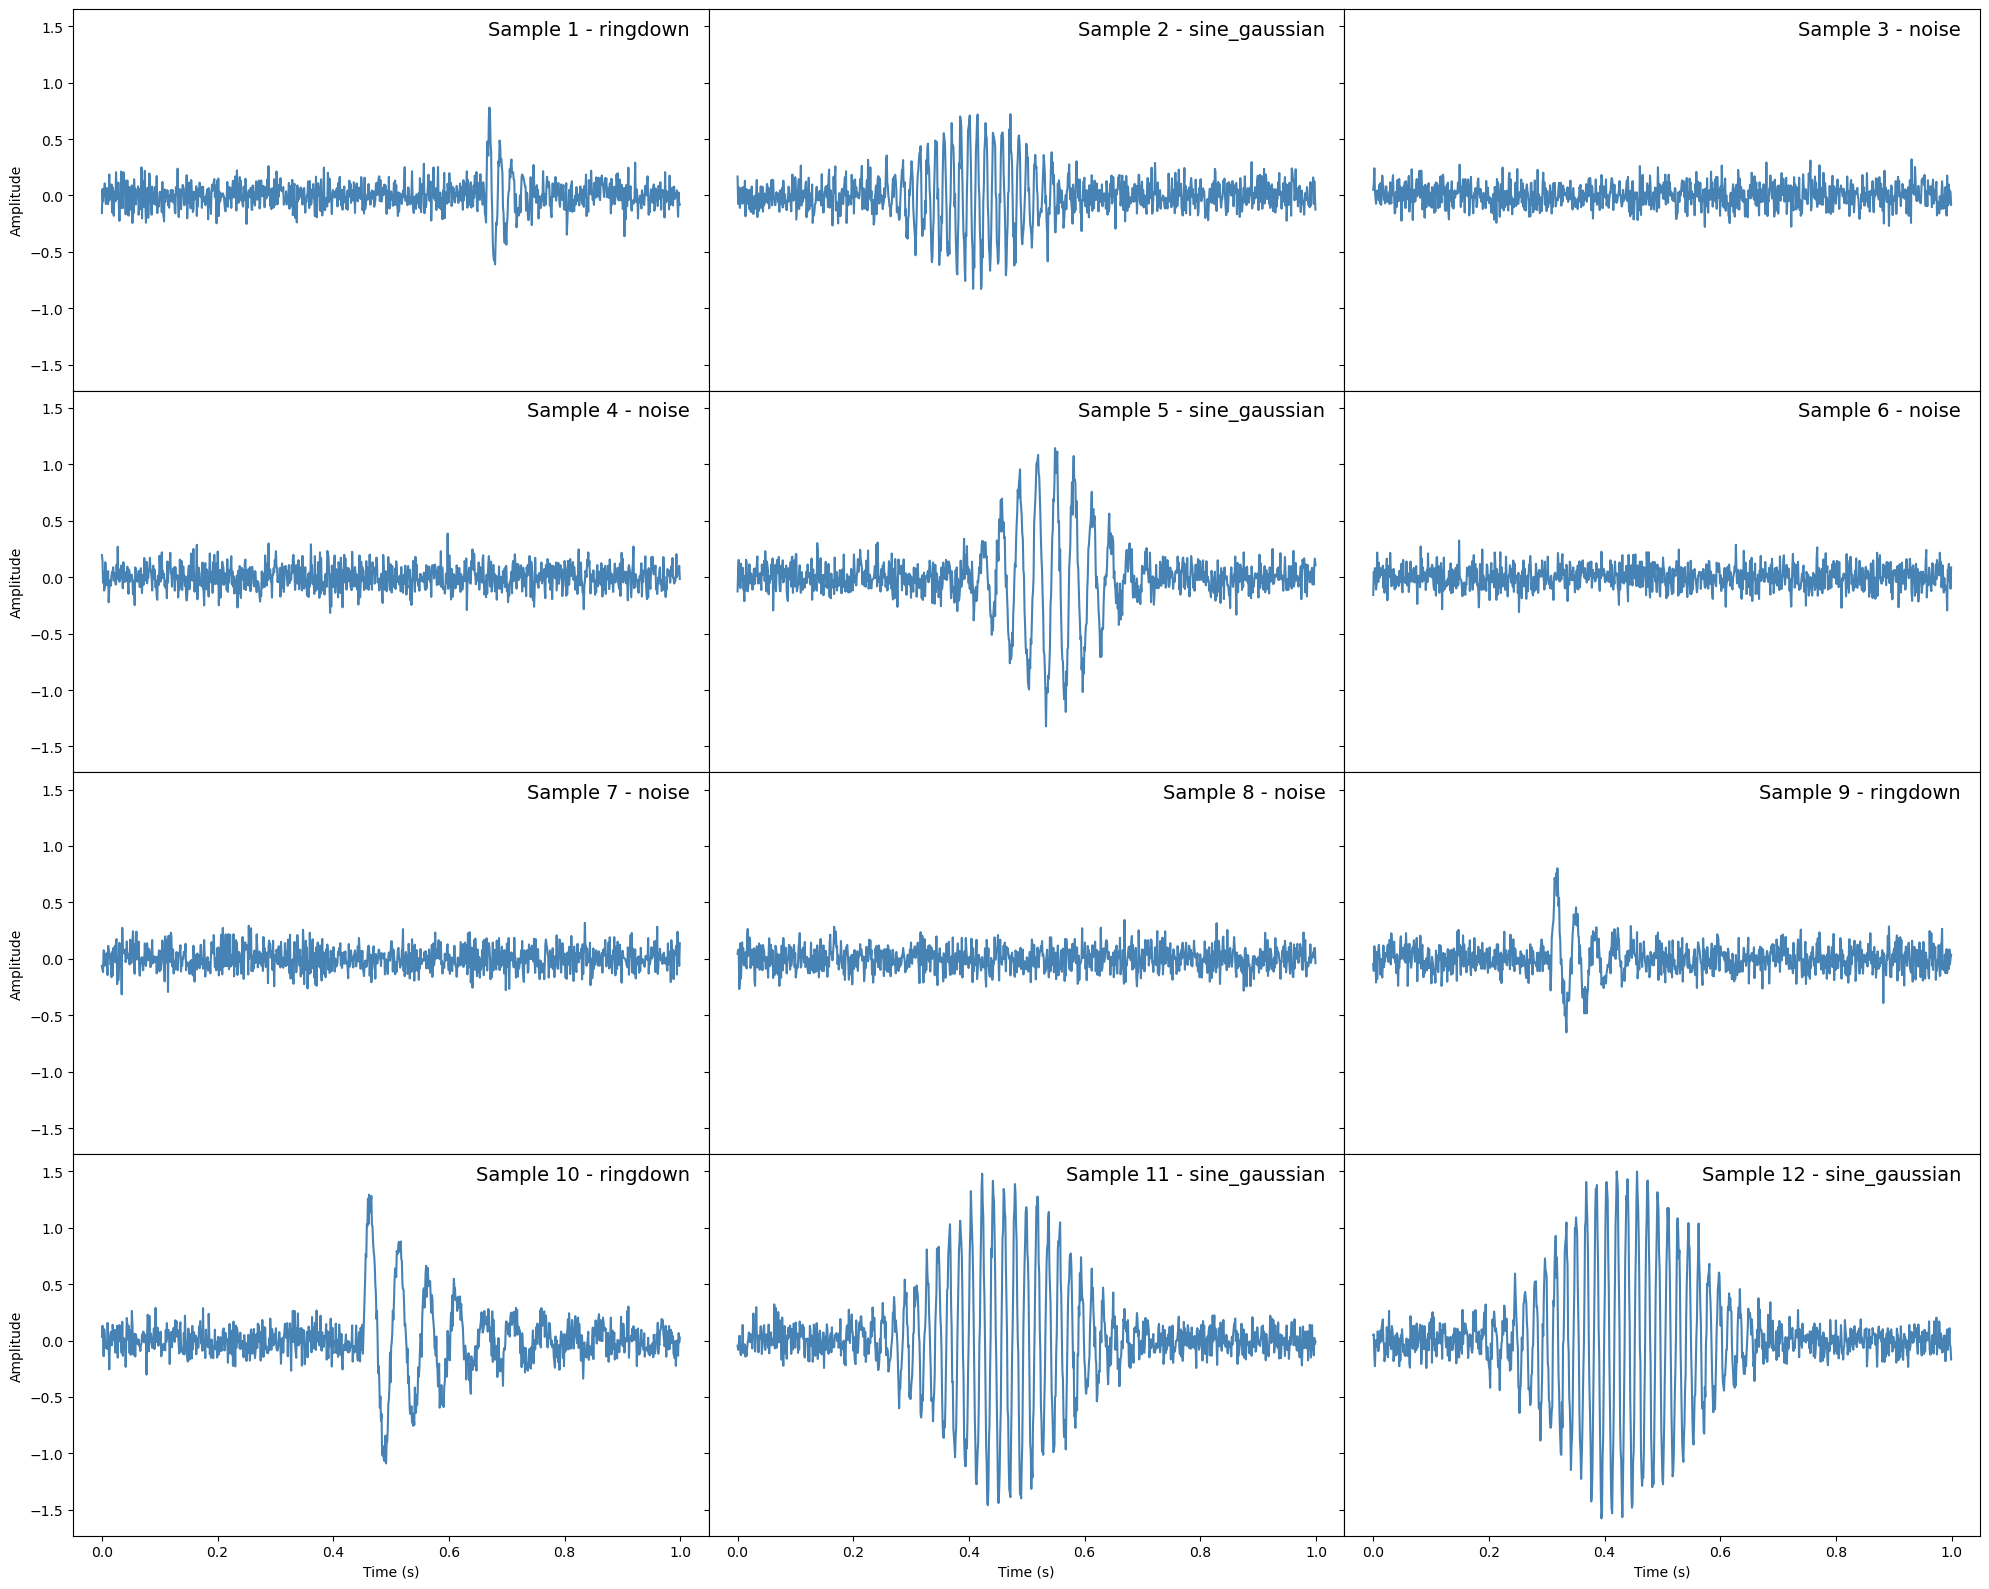

In [9]:
from signals import SignalGenerator
from dataset import DatasetGenerator
from plotting import plot_sample
import matplotlib.pyplot as plt

sg = SignalGenerator()
dg = DatasetGenerator(signal_generator=sg, n_samples=10000)

signals, t, y, metadata = dg.generate_dataset(glitch_type=None)
#print(metadata)

fig, axes = plt.subplots(4, 3, sharex=True, sharey=True, figsize=(20,16), gridspec_kw={'wspace': 0.0, 'hspace': 0.0})
for i in range(12):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    fig.add_gridspec(4, 3) # Ensure the grid spec is added to the figure
    ax.plot(t, signals[i], color='steelblue')
    ax.set_title(f'Sample {i+1} - {metadata[i]["glitch_type"]}', fontsize=14, loc='right', y=0.95, x=0.97, horizontalalignment='right', verticalalignment='top')
    if row == 3: # Only set y-label for the bottom row
        ax.set_xlabel('Time (s)')
    if col == 0: # Only set x-label for the leftmost column
        ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

## G) Visualize the spectrogram dataset

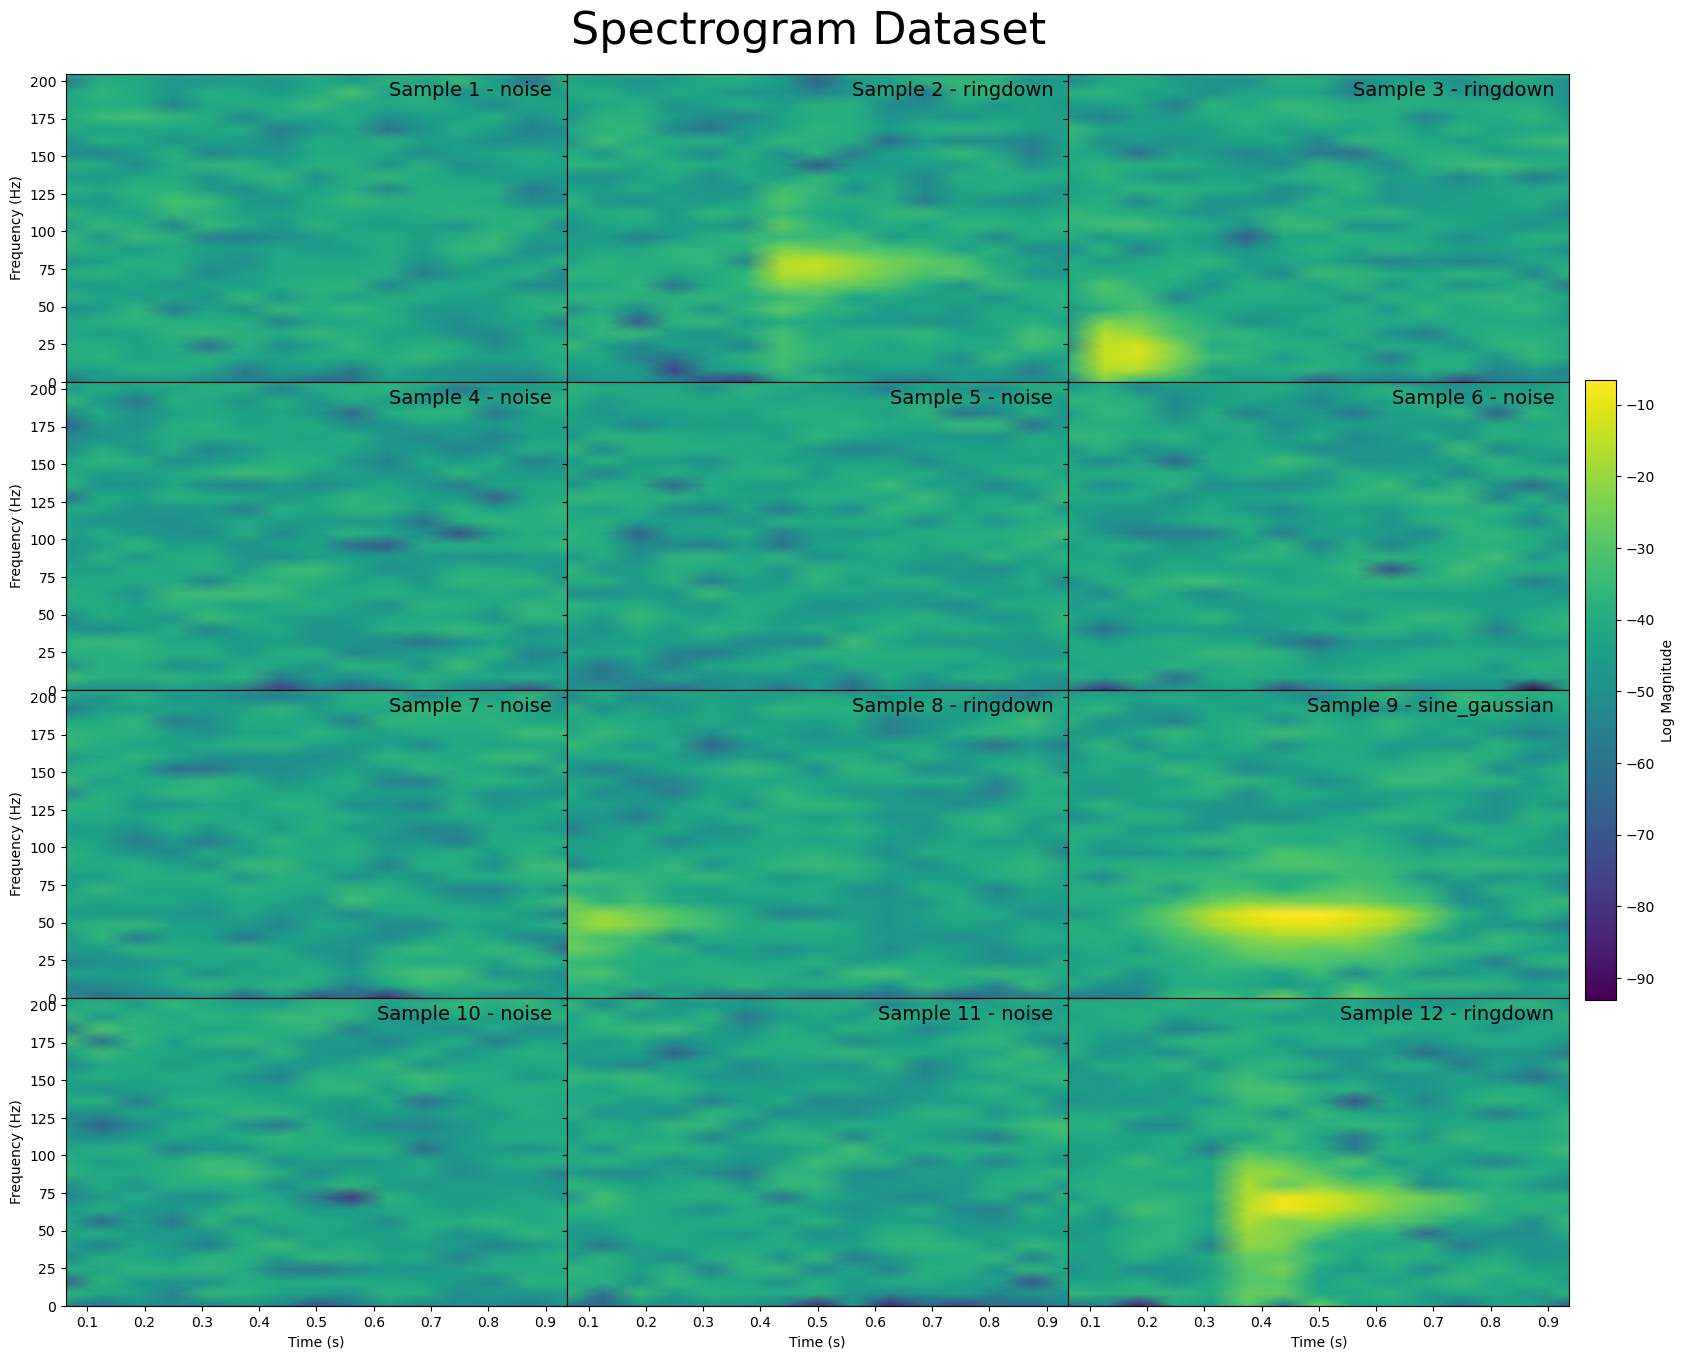

In [10]:
from signals import SignalGenerator
from dataset import DatasetGenerator
from features import FeatureExtractor
from plotting import plot_spectrogram

import numpy as np
import matplotlib.pyplot as plt

sg = SignalGenerator()
dg = DatasetGenerator(signal_generator=sg, n_samples=12)
fe = FeatureExtractor()

signals, t, y, metadata = dg.generate_dataset()
X_spec, f, t_spec = fe.build_spectrogram_dataset(signals)

fig, axes = plt.subplots(4, 3, sharex=True, sharey=True, figsize=(20,16), gridspec_kw={'wspace': 0.0, 'hspace': 0.0})

# Determine global vmin and vmax for consistent color scaling across all spectrograms
vmax = X_spec.max()
vmin = X_spec.min()

for i in range(12):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    # Plot the spectrogram for each sample
    ax.pcolormesh(t_spec, f, X_spec[i], vmin=vmin, vmax=vmax, cmap='viridis', shading='gouraud') #shading='auto' for pixelated look 

    if row == 3: # Only set x-label for the bottom row
        ax.set_xlabel('Time (s)')
    if col == 0: # Only set y-label for the leftmost column
        ax.set_ylabel('Frequency (Hz)')

    ax.set_title(f'Sample {i+1} - {metadata[i]["glitch_type"]}', fontsize=14, loc='right', y=0.95, x=0.97, horizontalalignment='right', verticalalignment='top')
    ax.set_ylim(0, sg.fs/5) # Limit frequency is Nyquist frequency is fs/2, but we can limit it to fs/5 to focus on the lower frequencies where the glitch is expected


plt.colorbar(plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes, orientation='vertical', fraction=0.02, pad=0.01, label='Log Magnitude')
plt.suptitle('Spectrogram Dataset ', fontsize=32, y=0.92)
plt.show()

## H) Transforming Spectrograms into features

 Here the Spectrograms are first **Flatten** and then **PCA** is applied.

Explained variance ratio: [0.02800601 0.01783226]
Total explained variance: 0.04583827184870039


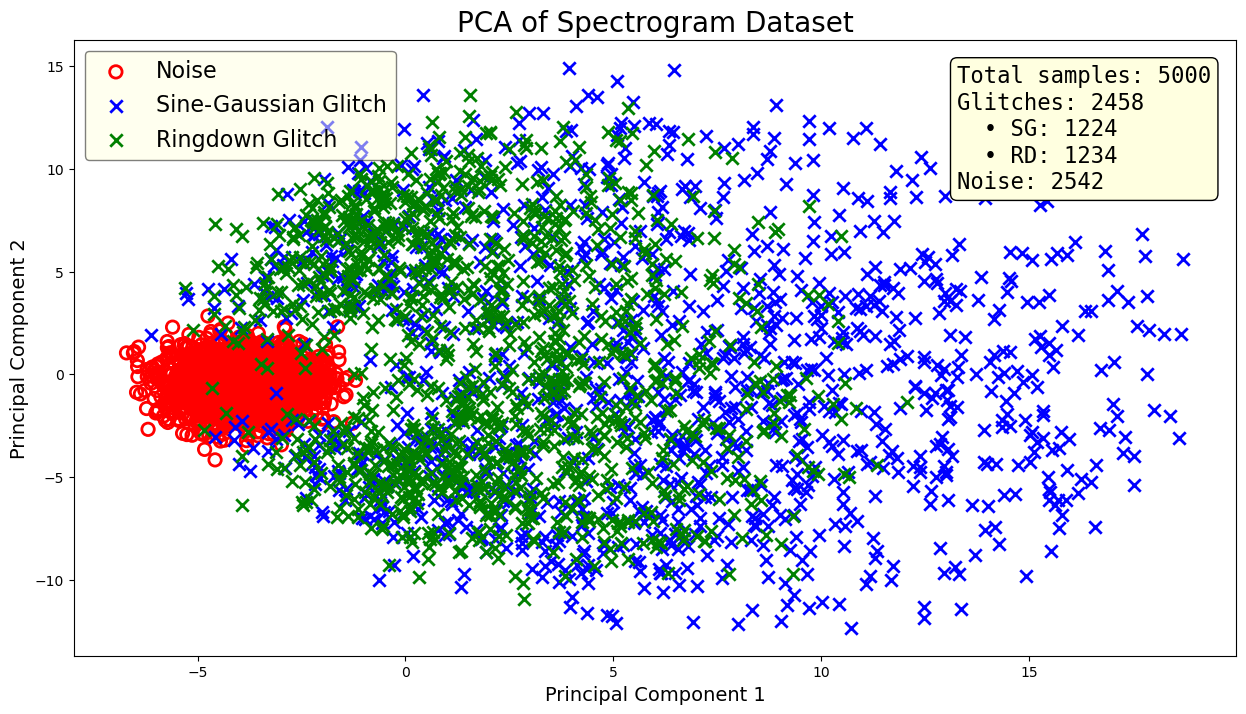

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

from signals import SignalGenerator
from dataset import DatasetGenerator
from features import FeatureExtractor

sg = SignalGenerator()
dg = DatasetGenerator(signal_generator=sg, n_samples=5000)
fe = FeatureExtractor()

#To visualize the feature space of the spectrogram dataset we generate 50 samples
signals, t, y, metadata = dg.generate_dataset()
X_spec, f, t_spec = fe.build_spectrogram_dataset(signals)

# Flatten spectrograms
X_flat = X_spec.reshape(X_spec.shape[0], -1)

# X_stand= (X_flat - X_flat.mean(axis=0))/ X_flat.std(axis=0)
# print("Mean of each feature before scaling:", X_stand.mean(axis=0)[0:10])
# print("Standard deviation of each feature before scaling:", X_stand.std(axis=0)[0:10])

# Scale features, PCA is sensitive to the scale of the features, so we standardize them to have mean=0 and variance=1 before applying PCA. 
# This ensures that PCA captures the true underlying structure of the data rather than being dominated by features with larger scales. 
# If the samples were normalized before applying PCA, this step would not be necessary.
# print(X_flat.mean(axis=1).shape, X_flat.std(axis=0).shape)
scaler = StandardScaler()
X_scale = scaler.fit_transform(X_flat)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scale)

# Explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_) # This gives the percentage of variance explained by each of the selected components.
print("Total explained variance:", pca.explained_variance_ratio_.sum()) # The sum of these two values will give us the total variance explained by the 2 principal components.


n_noise = np.sum(y==0) # Number of noise samples
n_glitches = len(y) - n_noise # Number of glitch samples

# Plot 
fig = plt.figure(figsize=(15,8))
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], marker="o", s=80, facecolor='none', label="Noise", alpha=1, linewidth=2, edgecolor='red') # alpha=0 makes the points invisible, but we keep the edgecolor to show the outline of the noise samples
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], marker="x", s=80, color="blue", label="Sine-Gaussian Glitch", alpha=1, linewidth=2)
plt.scatter(X_pca[y==2, 0], X_pca[y==2, 1], marker="x", s=80, color='green', label="Ringdown Glitch", alpha=1, linewidth=2)
plt.title("PCA of Spectrogram Dataset", fontsize=20)
plt.xlabel("Principal Component 1", fontsize=14)
plt.ylabel("Principal Component 2", fontsize=14)
plt.legend(loc='upper left', fontsize=16, framealpha=0.5, edgecolor='black', facecolor='lightyellow')
# Text to show in the box
text = (
    f"Total samples: {len(y)}\n"
    f"Glitches: {n_glitches}\n"
    f"  • SG: {np.sum(y==1)}\n"
    f"  • RD: {np.sum(y==2)}\n"
    f"Noise: {n_noise}"
)
plt.text(0.76, 0.96, text,
        transform=plt.gca().transAxes, verticalalignment='top', fontsize=16, fontfamily='monospace',
        bbox=dict(
            boxstyle='round,pad=0.3', 
            facecolor='lightyellow',  
            edgecolor='black'
        )
)
plt.show()